In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import requests
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 150,
    "figure.figsize": (12, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

RAW = "../data/raw/"
OUT = "../outputs/charts/"


In [4]:
# StatCan vector IDs for Canadian exports to the US by sector
# Source: Table 12-10-0011-01 (merchandise trade by country)
vectors = {
    'v1001064720': 'Total Exports to US',
    'v1001064721': 'Agricultural & Food',
    'v1001064722': 'Energy',
    'v1001064723': 'Forestry',
    'v1001064724': 'Industrial Goods',
    'v1001064725': 'Machinery & Equipment',
    'v1001064726': 'Automotive',
    'v1001064727': 'Consumer Goods',
    'v1001064728': 'Other Exports',
}

def get_statcan_vectors(vector_dict, start_date='2015-01-01'):
    """Pull multiple StatCan vectors via the Web Data Service API."""
    results = {}
    
    for vec_id, label in vector_dict.items():
        # Correct API endpoint for StatCan vector data
        url = f"https://www150.statcan.gc.ca/t1/tbl1/en/dtl!downloadDb?pid=1210001101&vect={vec_id}&downloadformat=csv"
        
        try:
            print(f"Fetching {label}...")
            r = requests.get(url, timeout=30)
            
            if r.status_code == 200:
                from io import StringIO
                df = pd.read_csv(StringIO(r.text))
                
                # The CSV has REF_DATE and VALUE columns
                if 'REF_DATE' in df.columns and 'VALUE' in df.columns:
                    df['date'] = pd.to_datetime(df['REF_DATE'])
                    df = df[df['date'] >= start_date]
                    df.set_index('date', inplace=True)
                    results[label] = df['VALUE']
                else:
                    print(f"Unexpected columns for {label}: {df.columns.tolist()}")
            else:
                print(f"HTTP {r.status_code} for {label}")
                
        except Exception as e:
            print(f"Failed for {label}: {e}")
    
    if results:
        return pd.DataFrame(results)
    return None

df_exports = get_statcan_vectors(vectors)

if df_exports is not None:
    df_exports = df_exports[df_exports.index >= '2015-01-01']
    print(f"Data shape: {df_exports.shape}")
    print(f"Date range: {df_exports.index.min()} to {df_exports.index.max()}")
    print("\nLast 3 rows:")
    print(df_exports.tail(3))
else:
    print("API call failed - will use fallback data")
    

Fetching Total Exports to US...
HTTP 404 for Total Exports to US
Fetching Agricultural & Food...
HTTP 404 for Agricultural & Food
Fetching Energy...
HTTP 404 for Energy
Fetching Forestry...
HTTP 404 for Forestry
Fetching Industrial Goods...
HTTP 404 for Industrial Goods
Fetching Machinery & Equipment...
HTTP 404 for Machinery & Equipment
Fetching Automotive...
HTTP 404 for Automotive
Fetching Consumer Goods...
HTTP 404 for Consumer Goods
Fetching Other Exports...
HTTP 404 for Other Exports
API call failed - will use fallback data


In [5]:
# Annual Canadian exports to US by sector ($ billions, customs basis)
# Source: Statistics Canada, Canadian International Merchandise Trade, annual
export_data = {
    'Year': [2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Energy':               [71.2, 53.1, 68.4, 91.2, 82.1, 54.3, 96.4, 152.1, 128.3, 118.6],
    'Automotive':           [68.4, 71.2, 72.1, 73.8, 70.2, 49.8, 67.3, 74.2,  76.1,  78.3],
    'Machinery & Equipment':[38.2, 37.8, 39.4, 41.2, 40.8, 35.6, 41.2, 46.8,  48.2,  49.1],
    'Agricultural & Food':  [28.4, 29.1, 30.2, 31.8, 33.2, 32.1, 37.4, 42.1,  44.8,  46.2],
    'Industrial Goods':     [32.1, 30.4, 33.8, 36.2, 34.8, 28.4, 36.8, 44.2,  42.1,  41.8],
    'Forestry':             [14.2, 13.8, 15.4, 13.2, 12.8, 11.4, 16.2, 15.8,  13.4,  13.1],
    'Consumer Goods':       [12.4, 12.8, 13.2, 13.8, 14.2, 13.1, 15.4, 17.2,  18.1,  18.8],
}

df_exp = pd.DataFrame(export_data).set_index('Year')
df_exp['Total'] = df_exp.sum(axis=1)

print(df_exp)


      Energy  Automotive  Machinery & Equipment  Agricultural & Food  \
Year                                                                   
2015    71.2        68.4                   38.2                 28.4   
2016    53.1        71.2                   37.8                 29.1   
2017    68.4        72.1                   39.4                 30.2   
2018    91.2        73.8                   41.2                 31.8   
2019    82.1        70.2                   40.8                 33.2   
2020    54.3        49.8                   35.6                 32.1   
2021    96.4        67.3                   41.2                 37.4   
2022   152.1        74.2                   46.8                 42.1   
2023   128.3        76.1                   48.2                 44.8   
2024   118.6        78.3                   49.1                 46.2   

      Industrial Goods  Forestry  Consumer Goods  Total  
Year                                                     
2015              3

In [6]:
cols = ['REF_DATE', 'Seasonal adjustment', 'Prices', 
        'North American Industry Classification System (NAICS)', 'VALUE']

df_gdp_raw = pd.read_csv(RAW + "36100434.csv", usecols=cols)
df_gdp_raw['date'] = pd.to_datetime(df_gdp_raw['REF_DATE'])

# Filter to seasonally adjusted, chained dollars, 2015+
mask = (
    (df_gdp_raw['Seasonal adjustment'] == 'Seasonally adjusted at annual rates') &
    (df_gdp_raw['Prices'] == 'Chained (2017) dollars') &
    (df_gdp_raw['date'] >= '2015-01-01')
)

df_gdp = df_gdp_raw[mask].copy()
df_gdp.rename(columns={
    'North American Industry Classification System (NAICS)': 'industry'
}, inplace=True)

print(f"Rows: {len(df_gdp):,}")
print(df_gdp['industry'].unique()[:15])


Rows: 33,864
<StringArray>
[                                         'All industries [T001]',
                              'Goods-producing industries [T002]',
                           'Services-producing industries [T003]',
                              'Business sector industries [T004]',
                          'Non-business sector industries [T007]',
                                   'Industrial production [T010]',
                    'Non-durable manufacturing industries [T011]',
                        'Durable manufacturing industries [T012]',
         'Information and communication technology sector [T013]',
 'Information and communication technology, manufacturing [T014]',
      'Information and communication technology, services [T015]',
                                           'Energy sector [T016]',
                                           'Public sector [T018]',
                'Agriculture, forestry, fishing and hunting [11]',
                               'Cro

In [7]:
industry_map = {
    'All industries [T001]':                          'Total Economy',
    'Agriculture, forestry, fishing and hunting [11]': 'Agriculture & Forestry',
    'Mining, quarrying, and oil and gas extraction [21]': 'Energy & Mining',
    'Manufacturing [31-33]':                          'Manufacturing',
    'Construction [23]':                              'Construction',
    'Wholesale trade [41]':                           'Wholesale Trade',
    'Transportation and warehousing [48-49]':         'Transportation',
    'Finance and insurance [52]':                     'Finance & Insurance',
    'Professional, scientific and technical services [54]': 'Prof. Services',
    'Public administration [91]':                     'Public Administration',
}

mask_ind = df_gdp['industry'].isin(industry_map.keys())
df_gdp_ind = df_gdp[mask_ind].copy()
df_gdp_ind['industry_short'] = df_gdp_ind['industry'].map(industry_map)

# Annual average GDP by industry
df_gdp_ind['year'] = df_gdp_ind['date'].dt.year
df_gdp_annual = df_gdp_ind.groupby(['year', 'industry_short'])['VALUE'].mean().unstack()

print(df_gdp_annual.tail(3))


industry_short  Agriculture & Forestry   Construction  Energy & Mining  \
year                                                                     
2024                      43432.000000  166101.000000    115371.000000   
2025                      46287.833333  169734.583333    119953.583333   
2026                      45737.000000  167982.750000    121879.750000   

industry_short  Finance & Insurance  Manufacturing  Prof. Services  \
year                                                                 
2024                  170451.000000  205867.000000   168486.000000   
2025                  177550.583333  200866.666667   168889.916667   
2026                  181214.250000  197073.750000   167993.250000   

industry_short  Public Administration  Total Economy  Transportation  \
year                                                                   
2024                    165551.000000   2.294944e+06        101939.0   
2025                    167430.333333   2.332937e+06        10

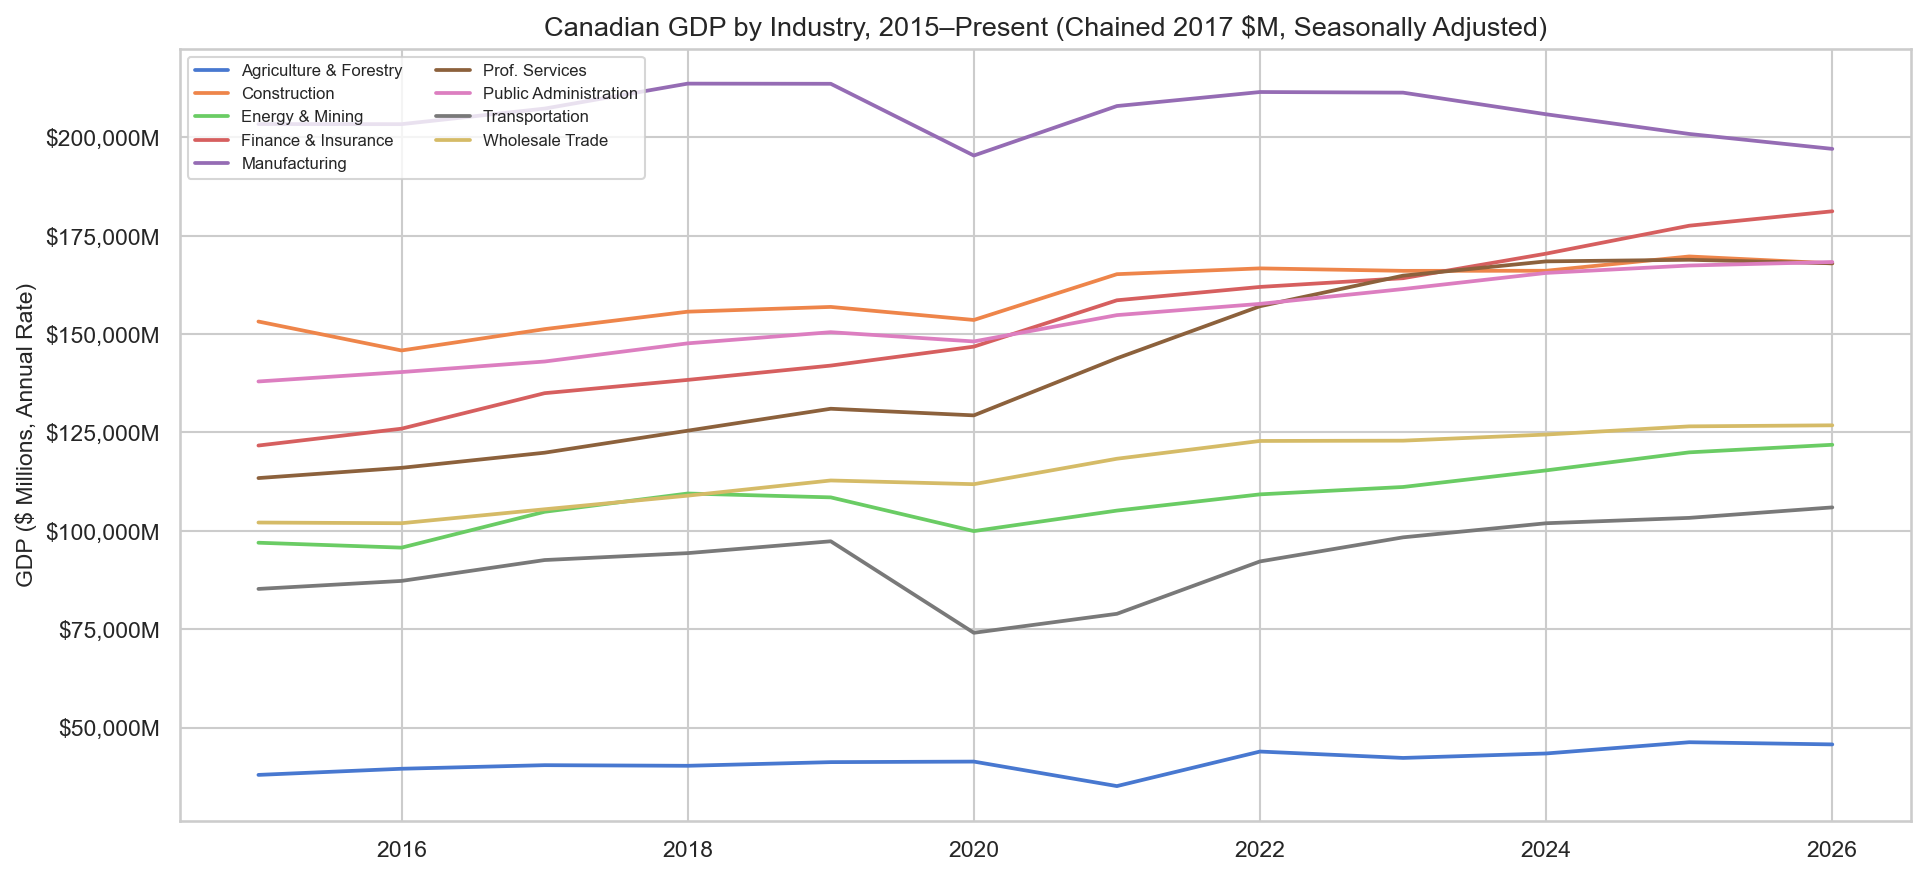

Saved.


In [8]:
fig, ax = plt.subplots(figsize=(13, 6))
df_gdp_annual.drop(columns='Total Economy').plot(ax=ax, linewidth=1.8)

ax.set_title("Canadian GDP by Industry, 2015–Present (Chained 2017 $M, Seasonally Adjusted)")
ax.set_ylabel("GDP ($ Millions, Annual Rate)")
ax.set_xlabel("")
ax.legend(loc='upper left', fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}M"))

plt.tight_layout()
plt.savefig(OUT + "01_gdp_by_industry.png")
plt.show()
print("Saved.")


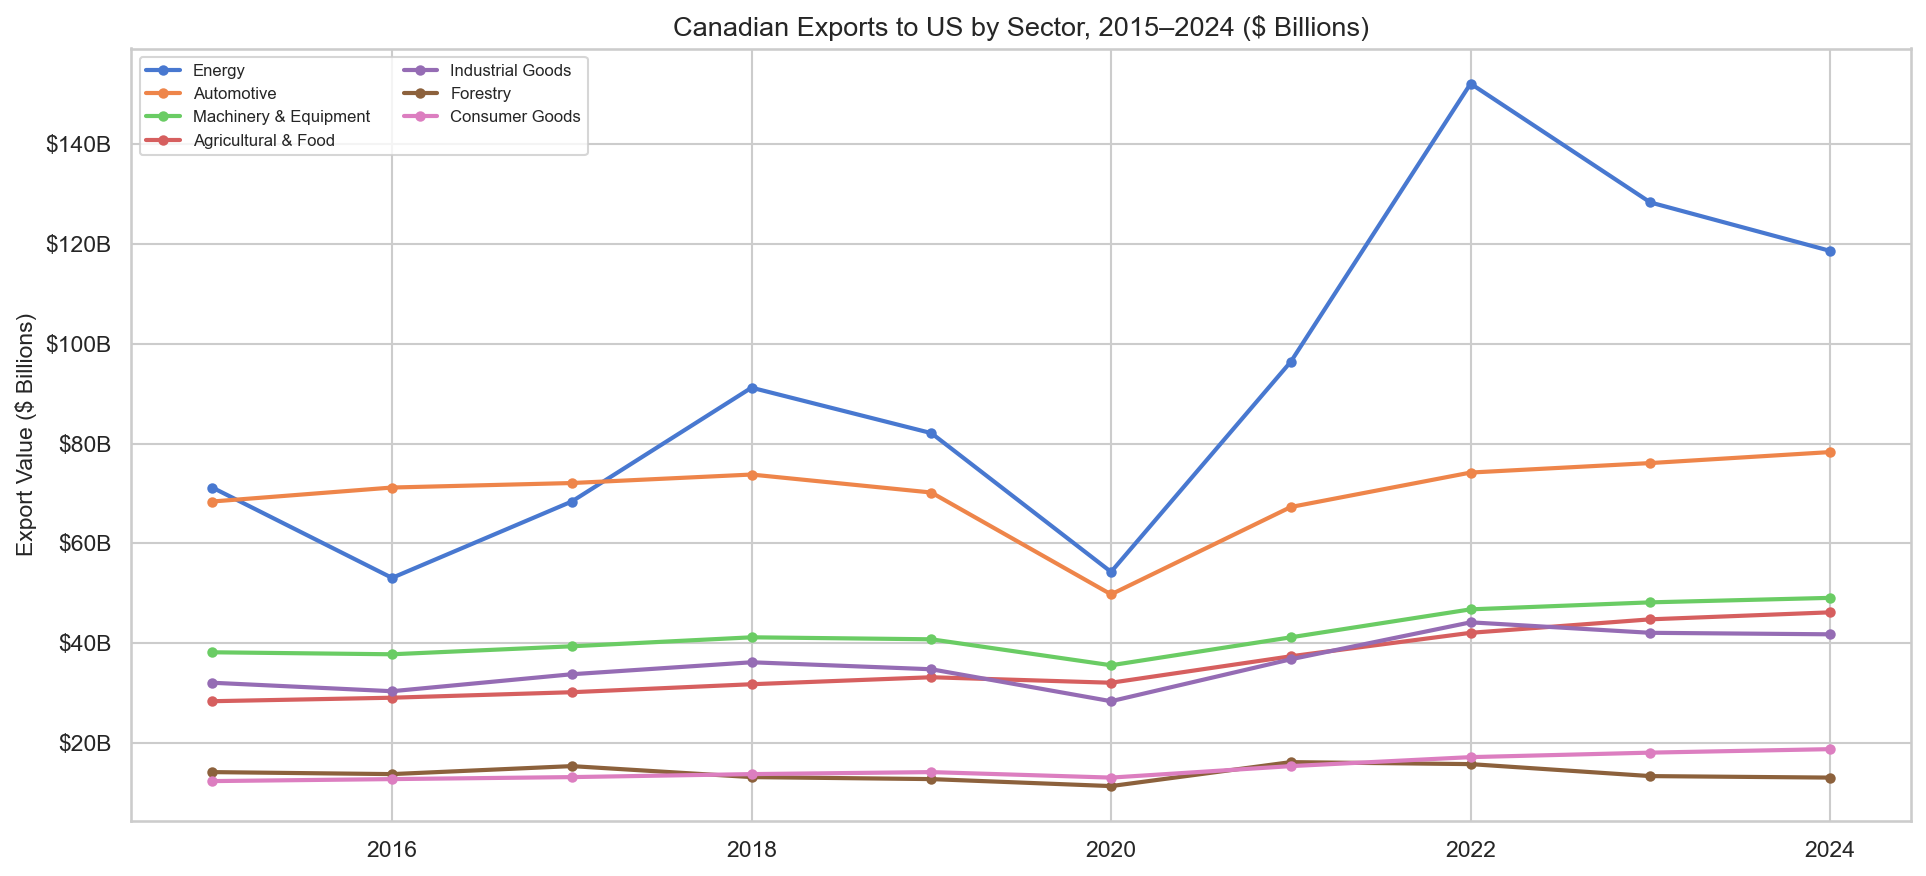

Saved.


In [9]:
sectors = ['Energy', 'Automotive', 'Machinery & Equipment',
           'Agricultural & Food', 'Industrial Goods', 'Forestry', 'Consumer Goods']

fig, ax = plt.subplots(figsize=(13, 6))
for sector in sectors:
    ax.plot(df_exp.index, df_exp[sector], linewidth=2, marker='o',
            markersize=4, label=sector)

ax.set_title("Canadian Exports to US by Sector, 2015–2024 ($ Billions)")
ax.set_ylabel("Export Value ($ Billions)")
ax.set_xlabel("")
ax.legend(fontsize=8, ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}B"))

plt.tight_layout()
plt.savefig(OUT + "02_exports_by_sector.png")
plt.show()
print("Saved.")


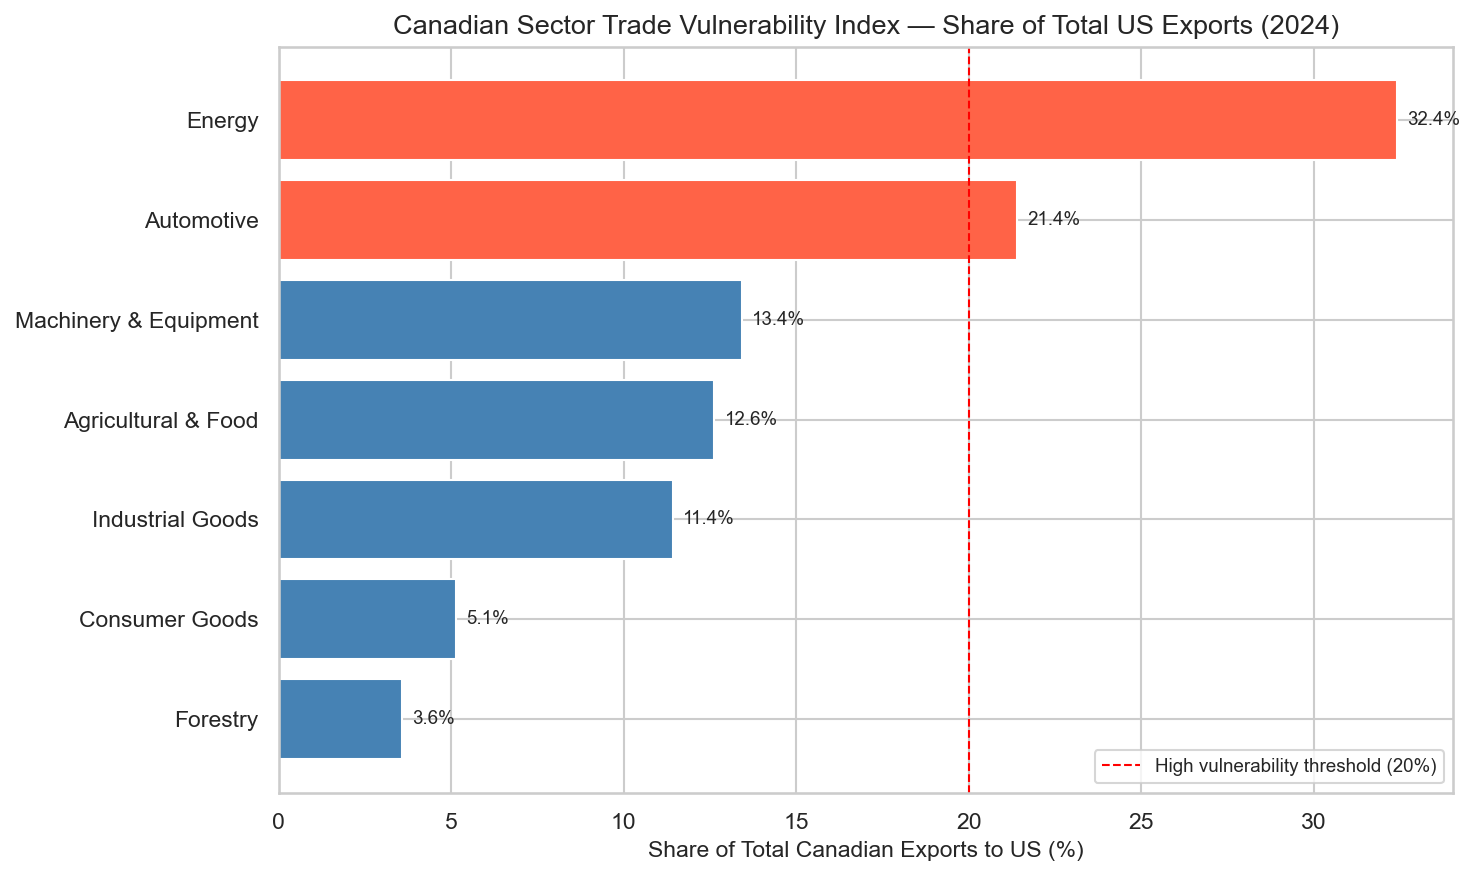

Saved.


In [10]:
# Vulnerability = Export Value / Total Exports (US concentration share)
# Higher share = more vulnerable to US trade disruption

latest_exports = df_exp.loc[2024, sectors]
total = latest_exports.sum()
vulnerability = (latest_exports / total * 100).sort_values(ascending=True)

colors = ['tomato' if v > 20 else 'steelblue' for v in vulnerability.values]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(vulnerability.index, vulnerability.values, color=colors)

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.3, bar.get_y() + bar.get_height()/2,
            f"{w:.1f}%", va='center', fontsize=9)

ax.axvline(x=20, color='red', linestyle='--', linewidth=1,
           label='High vulnerability threshold (20%)')
ax.set_title("Canadian Sector Trade Vulnerability Index — Share of Total US Exports (2024)")
ax.set_xlabel("Share of Total Canadian Exports to US (%)")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT + "03_vulnerability_index.png")
plt.show()
print("Saved.")


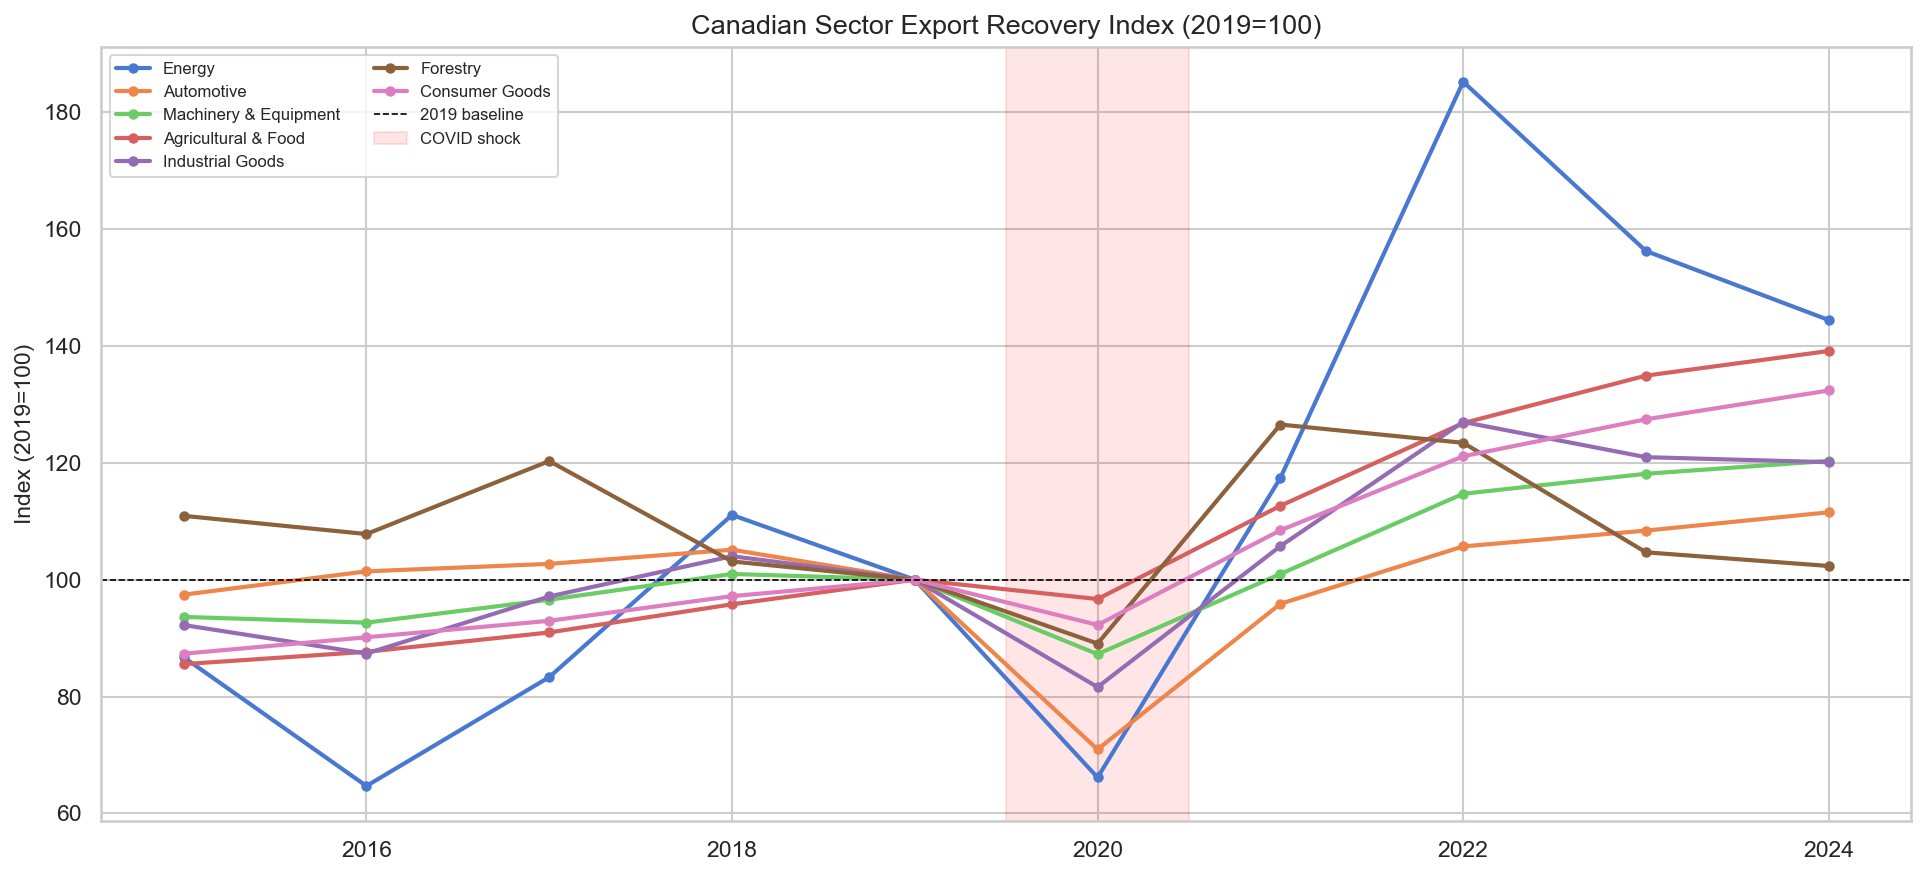

Saved.


In [11]:
# Show the COVID shock and recovery for each sector
df_indexed = df_exp[sectors].div(df_exp[sectors].loc[2019]) * 100

fig, ax = plt.subplots(figsize=(13, 6))
for sector in sectors:
    ax.plot(df_indexed.index, df_indexed[sector], linewidth=2,
            marker='o', markersize=4, label=sector)

ax.axhline(y=100, color='black', linewidth=0.8, linestyle='--', label='2019 baseline')
ax.axvspan(2019.5, 2020.5, alpha=0.1, color='red', label='COVID shock')

ax.set_title("Canadian Sector Export Recovery Index (2019=100)")
ax.set_ylabel("Index (2019=100)")
ax.set_xlabel("")
ax.legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(OUT + "04_export_recovery.png")
plt.show()
print("Saved.")


In [12]:
summary = pd.DataFrame({
    'Export Value 2024 ($B)': df_exp.loc[2024, sectors].round(1),
    'US Share (%)': (df_exp.loc[2024, sectors] / df_exp.loc[2024, sectors].sum() * 100).round(1),
    'COVID Low (2020, $B)': df_exp.loc[2020, sectors].round(1),
    'Recovery vs 2019 (%)': ((df_exp.loc[2024, sectors] / df_exp.loc[2019, sectors] - 1) * 100).round(1),
}).sort_values('US Share (%)', ascending=False)

print(summary.to_string())


                       Export Value 2024 ($B)  US Share (%)  COVID Low (2020, $B)  Recovery vs 2019 (%)
Energy                                  118.6          32.4                  54.3                  44.5
Automotive                               78.3          21.4                  49.8                  11.5
Machinery & Equipment                    49.1          13.4                  35.6                  20.3
Agricultural & Food                      46.2          12.6                  32.1                  39.2
Industrial Goods                         41.8          11.4                  28.4                  20.1
Consumer Goods                           18.8           5.1                  13.1                  32.4
Forestry                                 13.1           3.6                  11.4                   2.3
